In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [3]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\saoam\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [4]:
import sys
!{sys.executable} -m pip show matplotlib


Name: matplotlib
Version: 3.11.1
Summary: Python plotting package
Home-page: 
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib  alone or in any deri

In [5]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import tensorflow as tf

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [7]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [8]:
class_name = dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [9]:
len(dataset)

68

In [10]:
for image_batch, lable_batch in dataset.take(1):
    print(image_batch.shape)
    print(lable_batch.numpy())

(32, 256, 256, 3)
[1 0 0 0 0 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0]


In [11]:
for image_batch, lable_batch in dataset.take(1):
    print(image_batch[0].numpy())

[[[ 60.  62.  75.]
  [ 60.  62.  75.]
  [ 61.  63.  76.]
  ...
  [151. 141. 150.]
  [156. 146. 155.]
  [148. 138. 147.]]

 [[ 56.  58.  71.]
  [ 58.  60.  73.]
  [ 60.  62.  75.]
  ...
  [140. 130. 139.]
  [147. 137. 146.]
  [152. 142. 151.]]

 [[ 55.  57.  70.]
  [ 56.  58.  71.]
  [ 58.  60.  73.]
  ...
  [129. 119. 128.]
  [135. 125. 134.]
  [149. 139. 148.]]

 ...

 [[140. 133. 141.]
  [161. 154. 162.]
  [171. 164. 172.]
  ...
  [139. 129. 138.]
  [145. 135. 144.]
  [151. 141. 150.]]

 [[161. 154. 162.]
  [165. 158. 166.]
  [157. 150. 158.]
  ...
  [135. 125. 134.]
  [138. 128. 137.]
  [141. 131. 140.]]

 [[158. 151. 159.]
  [141. 134. 142.]
  [123. 116. 124.]
  ...
  [141. 131. 140.]
  [141. 131. 140.]
  [140. 130. 139.]]]


In [12]:
for image_batch, lable_batch in dataset.take(1):
    print(image_batch[0].shape)

(256, 256, 3)


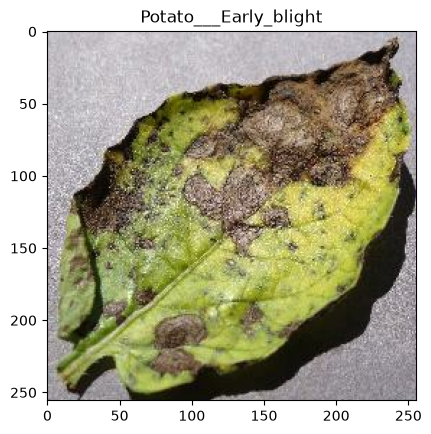

In [13]:

for image_batch, lable_batch in dataset.take(1):
     plt.imshow(image_batch[0].numpy().astype("uint8"))
     plt.title(class_name[lable_batch[0]])
       

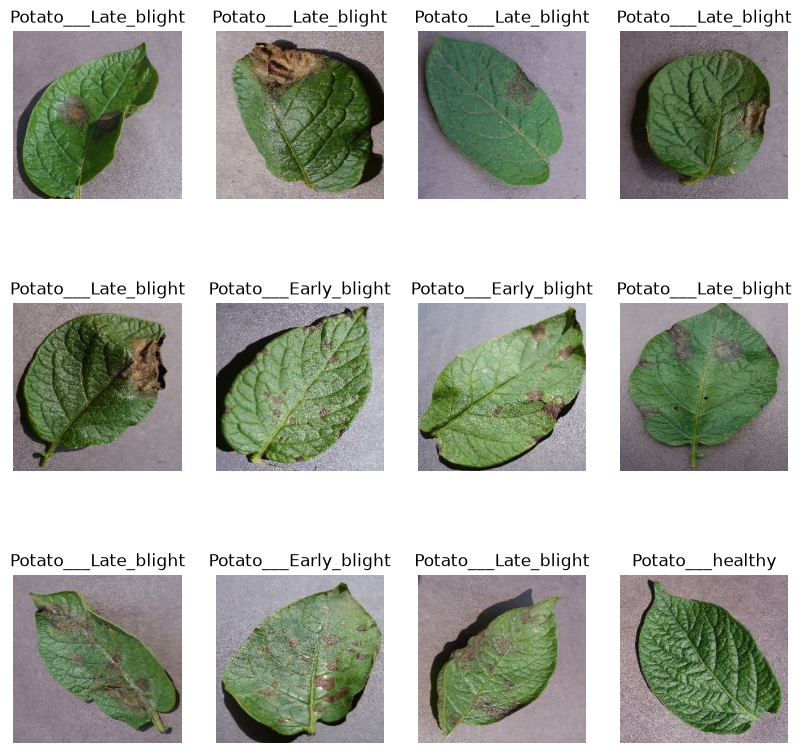

In [14]:
plt.figure(figsize=(10,10))
for image_batch, lable_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_name[lable_batch[i]])
        plt.axis("off")

In [15]:
len(dataset)

68

In [16]:
# 80% ==> traning
# 20% ==>  10% validation , 10% testing

In [17]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [18]:
train_ds = dataset.take(54)
len(train_ds)

54

In [19]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [20]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [21]:
val_ds =test_ds.take(6)
len(val_ds)

6

In [22]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [23]:
def get_dataset_partitions_tf(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size,seed = 12)
        train_size = int(train_split*ds_size)
        val_size = int(val_split*ds_size)
        test_size = int(test_split*ds_size)
        
        train_ds = ds.take(train_size)
        val_ds = ds.skip(train_size).take(val_size)
        
        return train_ds,val_ds,test_ds

In [24]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)


In [25]:
len(train_ds)


54

In [26]:
len(val_ds)

6

In [27]:
len(train_ds)

54

In [28]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [29]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])


In [30]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2)
])

In [31]:
# input_shape = [IMAGE_SIZE,IMAGE_SIZE,CHANNELS]
# n_classes = 3
# model = models.Sequential([
#     resize_and_rescale,
#     data_augmentation,
#     layers.Conv2D(32,(3,3), activation='relu', input_shape = input_shape),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64,kernel_size=(3,3), activation="relu"),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64,kernel_size=(3,3), activation="relu"),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64, (3,3), activation="relu"),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64, (3,3), activation="relu"),
#     layers.MaxPooling2D((2,2)),
#     layers.Conv2D(64, (3,3), activation="relu"),
#     layers.MaxPooling2D((2,2)),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(n_classes,activation='softmax')
#     ])
# model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

In [32]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer = "adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [35]:
EPOCHS = 10

history = model.fit(
    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data=val_ds
 )

Epoch 1/10


c:\Users\saoam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


54/54 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.4867 - loss: 0.8991 - val_accuracy: 0.6146 - val_loss: 0.8015
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.6800 - loss: 0.6673 - val_accuracy: 0.7188 - val_loss: 0.6121
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8171 - loss: 0.4299 - val_accuracy: 0.8958 - val_loss: 0.3016
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8733 - loss: 0.3037 - val_accuracy: 0.9271 - val_loss: 0.2371
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9167 - loss: 0.2352 - val_accuracy: 0.9375 - val_loss: 0.1544
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9161 - loss: 0.2147 - val_accuracy: 0.9740 - val_loss: 0.1263
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9167 - loss: 0.2038 - val_accuracy: 0.9844 - val_loss: 0.0822
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9155 - loss: 0.2187 - val_accuracy: 0.9740 - val_loss: 0.1048


In [36]:
scores = model.evaluate(test_ds)

print("Test Loss:", scores[0])
print("Test Accuracy:", scores[1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - accuracy: 0.9741 - loss: 0.0958
Test Loss: 0.0957745686173439
Test Accuracy: 0.9741379022598267


In [37]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [38]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

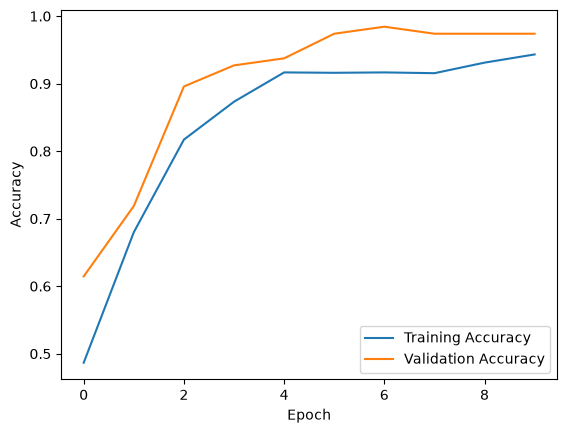

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

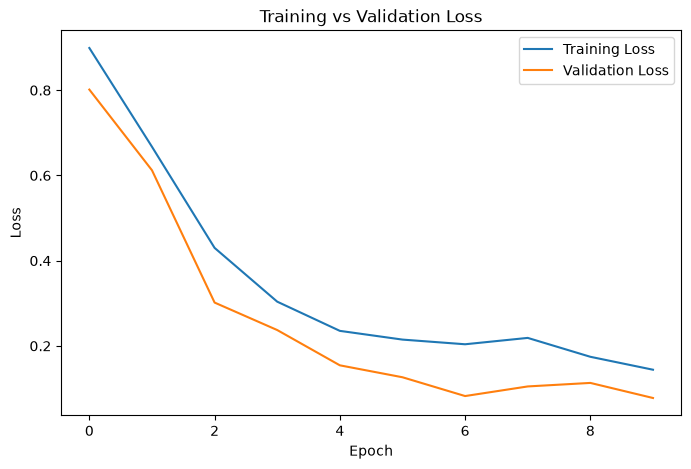

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [41]:
scores = model.evaluate(test_ds)

print("Test Loss:", scores[0])
print("Test Accuracy:", scores[1])
print("Test Accuracy %:", scores[1] * 100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 0.9741 - loss: 0.0958
Test Loss: 0.0957745611667633
Test Accuracy: 0.9741379022598267
Test Accuracy %: 97.41379022598267


first image to predict
actual lable Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
Prediction probabilities: [9.4560558e-01 5.4394294e-02 5.9514523e-08]
Actual class: Potato___Early_blight
Predicted class: Potato___Early_blight


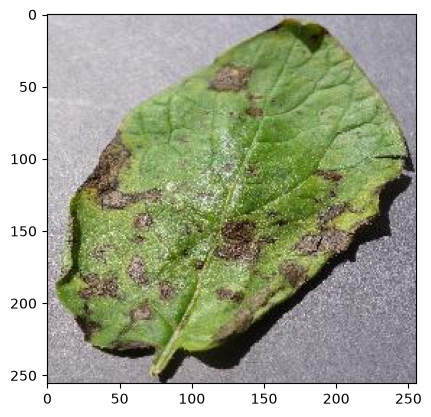

In [42]:
import numpy as np
for image_batch, lable_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_lable = lable_batch[0]
    
    print('first image to predict')
    plt.imshow(first_image)
    print('actual lable',class_name[first_lable])
    
    batch_prediction = model.predict(image_batch)
    first_prediction = batch_prediction[0]
    print("Prediction probabilities:", first_prediction)
    
    predicted_class = np.argmax(first_prediction)

    print("Actual class:", class_name[first_lable])
    print("Predicted class:", class_name[predicted_class])

In [43]:

predicted_class = np.argmax(first_prediction)

print("Actual class:", class_name[first_lable])
print("Predicted class:", class_name[predicted_class])

Actual class: Potato___Early_blight
Predicted class: Potato___Early_blight


In [44]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", y_true)
print("Predicted labels:", y_pred)

Actual labels: [1 0 0 0 1 1 0 0 2 2 0 0 0 1 0 1 1 1 1 0 0 1 1 0 1 2 1 0 0 0 1 1 2 1 0 1 1
 0 1 1 1 0 0 1 0 0 1 0 2 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 2 1 0 1 1
 1 1 0 0 0 0 0 0 0 0 0 2 2 1 0 0 0 1 1 2 0 0 0 0 0 0 1 1 0 0 2 1 2 0 1 1 1
 1 1 0 1 1 1 0 2 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 2 2 1 1 1 1 1 1
 0 1 0 0 0 2 0 1 0 0 0 1 1 2 1 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 2 0 0 1
 0 1 1 1 0 0 1 1 0 2 1 0 1 1 1 1 1 2 0 0 0 1 0 2 1 1 0 1 2 1 1 1 2 1 0 0 1
 0 0 1 1 0 0 1 1 0 0]
Predicted labels: [1 0 0 0 1 1 0 0 2 2 0 0 0 1 0 1 0 1 1 0 0 1 1 0 1 2 1 0 0 0 1 1 2 1 0 1 1
 0 0 1 1 0 0 1 0 0 1 0 2 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 2 1 0 1 1
 1 1 0 0 1 0 0 0 0 0 0 2 2 1 0 0 0 1 1 2 0 0 0 1 0 0 2 1 0 0 2 1 2 0 1 1 1
 1 1 0 1 1 1 0 2 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 2 2 1 1 1 1 1 1
 0 1 0 0 0 2 0 1 0 0 0 1 1 2 1 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 2 0 1 1
 0 1 1 1 0 0 1 1 0 2 1 0 1 1 1 1 1 2 0 0 0 1 0 2 1 1 0 1 2 1 1 1 2 1 0 0 1
 0 0 1 1 0 0 1 1 0 0]


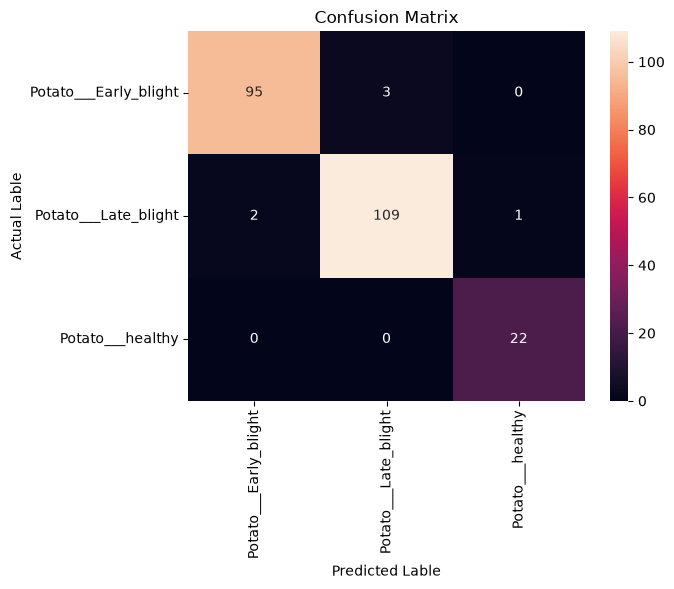

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true,y_pred)
plt.Figure(figsize=(7,5))
sns.heatmap(
    cm,annot=True,
    fmt='d',
    xticklabels=class_name,
    yticklabels=class_name
)
plt.xlabel("Predicted Lable")
plt.ylabel("Actual Lable")
plt.title("Confusion Matrix")
plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_name
))

                       precision    recall  f1-score   support

Potato___Early_blight       0.98      0.97      0.97        98
 Potato___Late_blight       0.97      0.97      0.97       112
     Potato___healthy       0.96      1.00      0.98        22

             accuracy                           0.97       232
            macro avg       0.97      0.98      0.98       232
         weighted avg       0.97      0.97      0.97       232



In [76]:
image_path = "E:\Ml project\Potato_disease\PlantVillage\Potato___Late_blight\0d8346e1-4624-4979-84e6-1353ca59007a___RS_LB 4079.JPG"

In [48]:
import os

print(os.path.exists(image_path))

False


In [49]:
print(repr(image_path))

'E:\\Ml project\\Potato_disease\\PlantVillage\\Potato___Late_blight\x00d8346e1-4624-4979-84e6-1353ca59007a___RS_LB 4079.JPG'


In [50]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

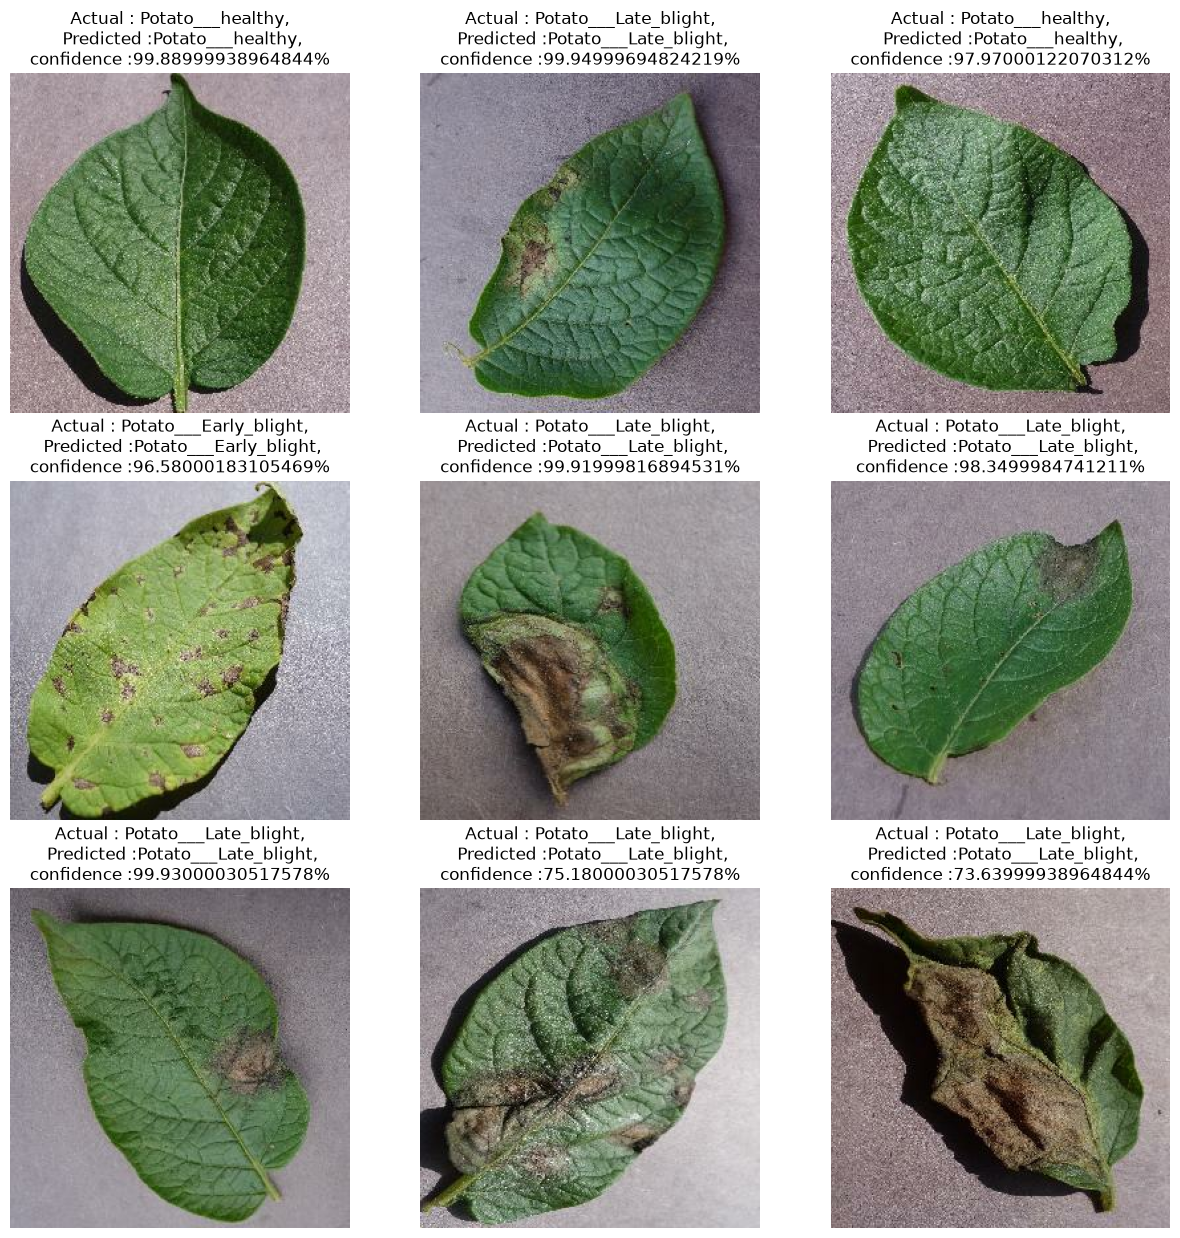

In [ ]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_name[labels[i]] 
        
        plt.axis('off')
        plt.title(f'Actual : {actual_class},\n Predicted :{predicted_class},\n confidence :{confidence}% ')

In [69]:
model.save("potato_disease_model.keras")

In [70]:
import os
print(os.path.exists("potato_disease_model.keras"))

True


In [71]:
loaded_model = tf.keras.models.load_model(
    'potato_disease_model.keras'
)

In [72]:
loaded_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,243 (2.10 MB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 367,496 (1.40 MB)